# 📘 Ejemplo de SVM Lineal y No Lineal en Python

En esta notebook veremos dos ejemplos de **Support Vector Machines (SVM)**:
- **SVM Lineal**: cuando los datos pueden separarse con una recta/hiperplano.
- **SVM No Lineal (RBF)**: cuando los datos necesitan una frontera curva.

Explicaremos los parámetros principales y evaluaremos los modelos con métricas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

## 🔹 1. SVM Lineal

Accuracy: 0.9666666666666667
Matriz de confusión:
 [[33  1]
 [ 1 25]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.96      0.96      0.96        26

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



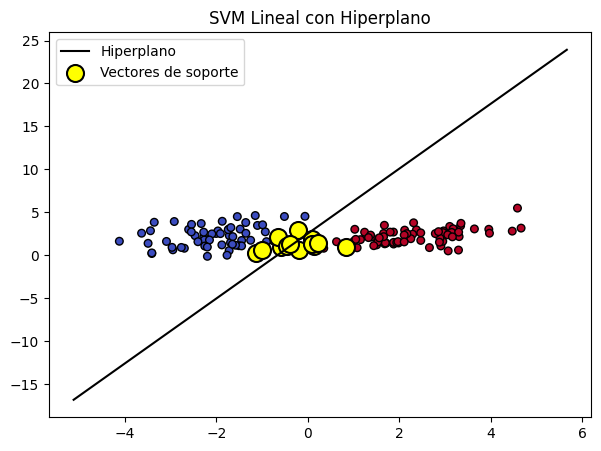

In [ ]:
# Generar datos separables linealmente
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin, test_size=0.3, random_state=42)

# Modelo SVM lineal
svm_linear = SVC(kernel='linear', C=1.0)


#C Controla el equilibrio entre lograr un margen amplio entre las clases y minimizar los errores de clasificación en el conjunto de entrenamiento.
#Es el "costo" o penalización por clasificar mal un dato. •
	#• C bajo: Permite un margen más amplio a costa de aceptar algunos errores de entrenamiento. Simplifica el modelo (más sesgo, menos varianza). Evita el sobreajuste (overfitting).
	#• C alto: Penaliza severamente los errores. El modelo intentará clasificar correctamente todos los puntos de entrenamiento, lo que puede resultar en un margen muy estrecho o una frontera sinuosa (menos sesgo, más varianza). Puede causar sobreajuste.

#• Define qué tan lejos llega la influencia de un solo punto de entrenamiento. Controla la curvatura de la frontera de decisión en kernels como el RBF.
#	• gamma bajo: La influencia de cada punto llega muy lejos. La frontera de decisión es suave, lineal y difusa (más sesgo, menos varianza).
#	• gamma alto: La influencia de cada punto es muy localizada. La frontera se ajusta firmemente alrededor de cada punto de entrenamiento, creando "islas" o formas complejas (menos sesgo, más varianza). Puede causar sobreajuste.


svm_linear.fit(X_train, y_train)

# Predicciones
y_pred_lin = svm_linear.predict(X_test)

# Métricas
print('Accuracy:', accuracy_score(y_test, y_pred_lin))
print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred_lin))
print('Reporte de clasificación:\n', classification_report(y_test, y_pred_lin))

# Graficar hiperplano lineal
w = svm_linear.coef_[0]
b = svm_linear.intercept_[0]
xx = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 200)
yy = -(w[0]/w[1])*xx - b/w[1]

plt.figure(figsize=(7,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=plt.cm.coolwarm, s=30, edgecolors='k')
plt.plot(xx, yy, 'k-', label='Hiperplano')
plt.scatter(svm_linear.support_vectors_[:,0], svm_linear.support_vectors_[:,1],
            s=150, facecolors='yellow', edgecolors='k', linewidths=1.5, label='Vectores de soporte')
plt.title('SVM Lineal con Hiperplano')
plt.legend()
plt.show()

## 🔹 2. SVM No Lineal (Kernel RBF)

Accuracy: 0.9833333333333333
Matriz de confusión:
 [[32  0]
 [ 1 27]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.96      0.98        28

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



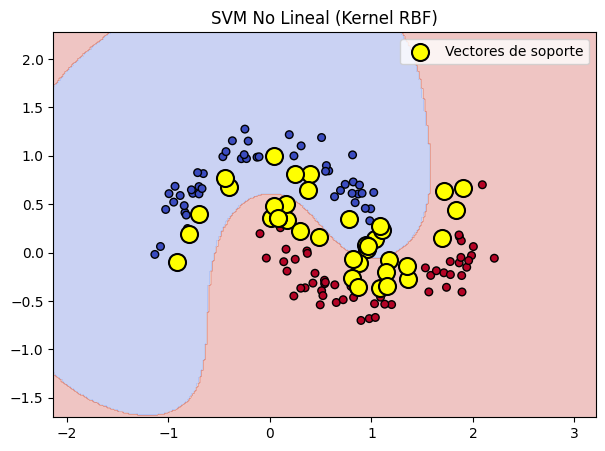

In [ ]:
# Generar datos no lineales (moons dataset)
X_nl, y_nl = make_moons(n_samples=200, noise=0.15, random_state=42)
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_nl, y_nl, test_size=0.3, random_state=42)

# Modelo SVM no lineal
svm_rbf = SVC(kernel='rbf', C=1.0, gamma=1.0)

#GAMMA • Define qué tan lejos llega la influencia de un solo punto de entrenamiento. Controla la curvatura de la frontera de decisión en kernels como el RBF.
	#• gamma bajo: La influencia de cada punto llega muy lejos. La frontera de decisión es suave, lineal y difusa (más sesgo, menos varianza).
	#• gamma alto: La influencia de cada punto es muy localizada.
      #La frontera se ajusta firmemente alrededor de cada punto de entrenamiento, creando "islas" o formas complejas (menos sesgo, más varianza). Puede causar sobreajuste.

svm_rbf.fit(X_train_nl, y_train_nl)

# Predicciones
y_pred_nl = svm_rbf.predict(X_test_nl)

# Métricas
print('Accuracy:', accuracy_score(y_test_nl, y_pred_nl))
print('Matriz de confusión:\n', confusion_matrix(y_test_nl, y_pred_nl))
print('Reporte de clasificación:\n', classification_report(y_test_nl, y_pred_nl))

# Graficar frontera curva
xx, yy = np.meshgrid(np.linspace(X_train_nl[:,0].min()-1, X_train_nl[:,0].max()+1, 300),
                     np.linspace(X_train_nl[:,1].min()-1, X_train_nl[:,1].max()+1, 300))
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_nl[:,0], X_train_nl[:,1], c=y_train_nl, cmap=plt.cm.coolwarm, s=30, edgecolors='k')
plt.scatter(svm_rbf.support_vectors_[:,0], svm_rbf.support_vectors_[:,1],
            s=150, facecolors='yellow', edgecolors='k', linewidths=1.5, label='Vectores de soporte')
plt.title('SVM No Lineal (Kernel RBF)')
plt.legend()
plt.show()